In [1]:
import pandas as pd
data=pd.read_csv("advertising.csv")

In [2]:
data.shape

(200, 4)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
data.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [5]:
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [9]:
encoded_data = pd.get_dummies(data,dtype=int)

In [7]:
data.duplicated().sum()

np.int64(0)

In [10]:
encoded_data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [11]:
X = encoded_data.drop('Sales', axis=1)
y = encoded_data['Sales']               

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.50, random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression
Sales_predict=LinearRegression()
Sales_predict.fit(X_train, y_train)

LinearRegression()

In [14]:
Sales_predict.intercept_

np.float64(4.595967639337363)

In [15]:
Sales_predict.coef_

array([0.05442133, 0.10080321, 0.00938395])

In [16]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred_train = Sales_predict.predict(X_train)
train_error = mean_squared_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

In [17]:
train_error

2.921249619635661

In [18]:
train_r2

0.8911171517862451

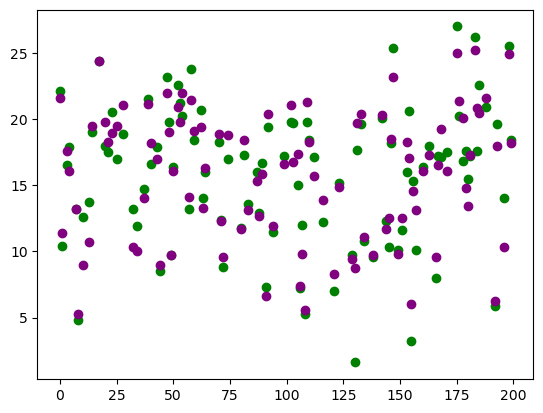

In [29]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(x=X_train.index,y=y_train,color="green")
plt.scatter(x=X_train.index,y=y_pred_train,color="purple")
plt.savefig("plot.png")
plt.show()

In [21]:
y_pred_test = Sales_predict.predict(X_test)
test_error = mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

In [22]:
test_r2

0.907313434112335

In [23]:
test_error

2.5790997191065395

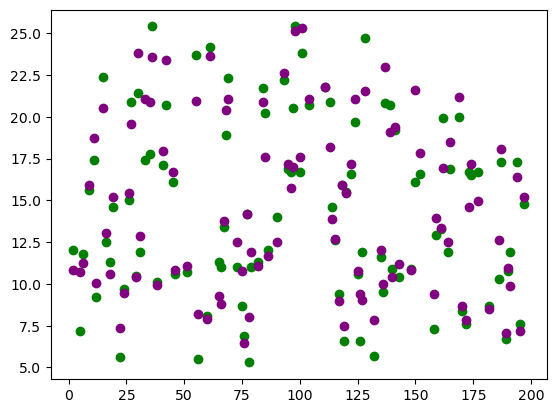

In [30]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(x=X_test.index,y=y_test,color="green")
plt.scatter(x=X_test.index,y=y_pred_test,color="purple")
plt.savefig("plot.png")
plt.show()

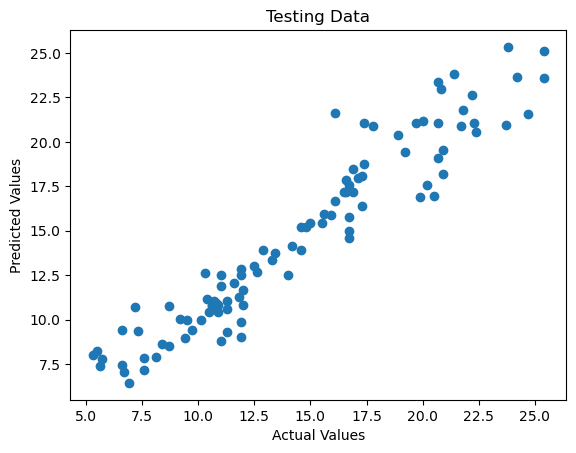

In [26]:
plt.figure()
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Testing Data")
plt.show()